# Prédiction de matchs LoL Pro — Modélisation
**Baseline** : XGBoost  
**Modèles DL** : TabNet (Arik & Pfister, 2021) · FT-Transformer (Gorishniy et al., NeurIPS 2021)  
**Approche** : Comparaison à 4 checkpoints temporels (10, 15, 20, 25 min)

In [1]:
# IMPORTANT : importer pytorch_tabnet AVANT xgboost (conflit DLL Windows)
from pytorch_tabnet.tab_model import TabNetClassifier
from xgboost import XGBClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, RocCurveDisplay

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import rtdl

import warnings, pickle
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
print('Imports OK')

Imports OK


In [2]:
def train_ftt(X_train_s, y_train, X_test_s, y_test,
              n_epochs=200, patience=20, batch_size=256):
    """Entraîne un FT-Transformer (Gorishniy et al., NeurIPS 2021) sur données tabulaires.
    Chaque feature est projetée en vecteur (Feature Tokenizer), puis un Transformer
    capture les interactions entre features via attention multi-têtes.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    n_features = X_train_s.shape[1]

    model = rtdl.FTTransformer.make_default(
        n_num_features=n_features,
        cat_cardinalities=None,
        d_out=1,
    ).to(device)

    optimizer = model.make_default_optimizer()

    X_tr = torch.FloatTensor(X_train_s).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    X_te = torch.FloatTensor(X_test_s).to(device)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    best_acc, patience_counter, best_state = 0, 0, None

    for epoch in range(n_epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            F.binary_cross_entropy_with_logits(
                model(xb, None).squeeze(1), yb
            ).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(X_te, None).squeeze(1)
            preds = (logits > 0).cpu().numpy()
            acc = accuracy_score(y_test, preds)

        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        logits = model(X_te, None).squeeze(1)
        probas = torch.sigmoid(logits).cpu().numpy()
    preds = (probas > 0.5).astype(int)

    return model.cpu(), preds, probas

print('FT-Transformer helper OK')

FT-Transformer helper OK


## 1. Chargement et définition des checkpoints

In [3]:
df = pd.read_csv('../data/data_cleaned.csv')
TARGET = 'result'

CONTEXT = ['side', 'firstblood']
FEATS_10 = CONTEXT + ['golddiffat10','xpdiffat10','csdiffat10','killsat10','assistsat10','deathsat10']
FEATS_15 = FEATS_10 + ['firstdragon','firstherald','firsttower','golddiffat15','xpdiffat15','csdiffat15','killsat15','assistsat15','deathsat15']
FEATS_20 = FEATS_15 + ['golddiffat20','xpdiffat20','csdiffat20','killsat20','assistsat20','deathsat20']
FEATS_25 = FEATS_20 + ['firstbaron','golddiffat25','xpdiffat25','csdiffat25','killsat25','assistsat25','deathsat25']

CHECKPOINTS = {'10 min': FEATS_10, '15 min': FEATS_15, '20 min': FEATS_20, '25 min': FEATS_25}

print('Matchs disponibles par checkpoint :')
for name, feats in CHECKPOINTS.items():
    n = len(df[feats + [TARGET]].dropna()) // 2
    print(f'  @{name} : {n} matchs, {len(feats)} features')

Matchs disponibles par checkpoint :
  @10 min : 9236 matchs, 8 features
  @15 min : 9236 matchs, 17 features
  @20 min : 9226 matchs, 23 features
  @25 min : 8892 matchs, 30 features


## 2. Entraînement — XGBoost vs TabNet vs FT-Transformer à chaque checkpoint

**XGBoost** est la baseline : gradient boosting sur arbres de décision, référence sur les données tabulaires depuis 2016.

**TabNet** (Arik & Pfister, 2021) : réseau de neurones avec mécanisme d'**attention séquentielle**. À chaque étape de décision, un masque sélectionne les features les plus pertinentes, ce qui le rend à la fois performant et interprétable nativement.

**FT-Transformer** (Gorishniy et al., NeurIPS 2021) : chaque feature est encodée en un vecteur (*Feature Tokenizer*), puis un Transformer standard capture les **interactions entre features** via l'attention multi-têtes. Référence état de l'art sur données tabulaires (< 5 ans).

In [4]:
results = {}

for name, feats in CHECKPOINTS.items():
    print(f'\n{"="*50}')
    print(f'Checkpoint : @{name}')
    print(f'{"="*50}')

    subset = df[feats + [TARGET]].dropna()
    X = subset[feats].values
    y = subset[TARGET].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # --- XGBoost ---
    xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0
    )
    xgb.fit(X_train, y_train)
    yp_xgb     = xgb.predict(X_test)
    yproba_xgb = xgb.predict_proba(X_test)[:, 1]
    acc_xgb = accuracy_score(y_test, yp_xgb)
    f1_xgb  = f1_score(y_test, yp_xgb)
    auc_xgb = roc_auc_score(y_test, yproba_xgb)
    print(f'XGBoost     -> Acc: {acc_xgb:.4f} | F1: {f1_xgb:.4f} | AUC: {auc_xgb:.4f}')

    # --- TabNet ---
    tabnet = TabNetClassifier(
        n_d=32, n_a=32, n_steps=5, gamma=1.5,
        seed=RANDOM_STATE, verbose=0
    )
    tabnet.fit(
        X_train_s, y_train,
        eval_set=[(X_test_s, y_test)],
        eval_metric=['accuracy'],
        max_epochs=100, patience=15,
        batch_size=512, virtual_batch_size=128
    )
    yp_tab     = tabnet.predict(X_test_s)
    yproba_tab = tabnet.predict_proba(X_test_s)[:, 1]
    acc_tab = accuracy_score(y_test, yp_tab)
    f1_tab  = f1_score(y_test, yp_tab)
    auc_tab = roc_auc_score(y_test, yproba_tab)
    print(f'TabNet      -> Acc: {acc_tab:.4f} | F1: {f1_tab:.4f} | AUC: {auc_tab:.4f}')

    # --- FT-Transformer ---
    ftt_model, yp_ftt, yproba_ftt = train_ftt(X_train_s, y_train, X_test_s, y_test)
    acc_ftt = accuracy_score(y_test, yp_ftt)
    f1_ftt  = f1_score(y_test, yp_ftt)
    auc_ftt = roc_auc_score(y_test, yproba_ftt)
    print(f'FT-Transf.  -> Acc: {acc_ftt:.4f} | F1: {f1_ftt:.4f} | AUC: {auc_ftt:.4f}')

    results[name] = {
        'feats': feats, 'scaler': scaler,
        'xgb': {'model': xgb,       'acc': acc_xgb, 'f1': f1_xgb, 'auc': auc_xgb,
                'y_pred': yp_xgb,   'y_proba': yproba_xgb},
        'tab': {'model': tabnet,    'acc': acc_tab, 'f1': f1_tab, 'auc': auc_tab,
                'y_pred': yp_tab,   'y_proba': yproba_tab},
        'ftt': {'model': ftt_model, 'acc': acc_ftt, 'f1': f1_ftt, 'auc': auc_ftt,
                'y_pred': yp_ftt,   'y_proba': yproba_ftt},
        'y_test': y_test, 'X_test': X_test, 'X_test_s': X_test_s
    }

print('\nEntraînement terminé.')


Checkpoint : @10 min


XGBoost     -> Acc: 0.6796 | F1: 0.6802 | AUC: 0.7540



Early stopping occurred at epoch 54 with best_epoch = 39 and best_val_0_accuracy = 0.69608


TabNet      -> Acc: 0.6961 | F1: 0.7036 | AUC: 0.7658


FT-Transf.  -> Acc: 0.6961 | F1: 0.6914 | AUC: 0.7657

Checkpoint : @15 min


...

FT-Transf.  -> Acc: 0.7946 | F1: 0.7922 | AUC: 0.8757

Checkpoint : @25 min


XGBoost     -> Acc: 0.8794 | F1: 0.8805 | AUC: 0.9541



Early stopping occurred at epoch 44 with best_epoch = 29 and best_val_0_accuracy = 0.88586


TabNet      -> Acc: 0.8859 | F1: 0.8877 | AUC: 0.9541


FT-Transf.  -> Acc: 0.8861 | F1: 0.8882 | AUC: 0.9574

Entraînement terminé.


## 2b. Optimisation des hyperparamètres — FT-Transformer (Optuna)

Recherche bayésienne (**TPE sampler**) sur l'espace d'hyperparamètres du FT-Transformer via **Optuna**.

**Paramètres explorés** :
- Architecture : `d_token` ∈ {64, 128, 192, 256}, `n_blocks` ∈ [1, 4], `attention_n_heads` ∈ {4, 8}
- Régularisation : `attention_dropout`, `ffn_dropout`, `residual_dropout`, `ffn_factor`
- Optimiseur : `lr` (log-scale), `batch_size`

**Stratégie** : split train/val interne (80/20 du train), 20 essais par checkpoint, early stopping patience=10 sur l'AUC de validation.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_ftt_objective(X_train_s, y_train, X_val_s, y_val, n_features, device):
    def objective(trial):
        d_token      = trial.suggest_categorical('d_token', [64, 128, 192, 256])
        n_blocks     = trial.suggest_int('n_blocks', 1, 4)
        attn_drop    = trial.suggest_float('attention_dropout', 0.0, 0.3)
        ffn_factor   = trial.suggest_float('ffn_factor', 0.5, 4.0)
        ffn_d_hidden = max(int(d_token * ffn_factor) // 2 * 2, 4)
        ffn_drop     = trial.suggest_float('ffn_dropout', 0.0, 0.3)
        res_drop     = trial.suggest_float('residual_dropout', 0.0, 0.2)
        lr           = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
        batch_size   = trial.suggest_categorical('batch_size', [128, 256, 512])

        try:
            model = rtdl.FTTransformer.make_baseline(
                n_num_features=n_features, cat_cardinalities=None,
                d_token=d_token, n_blocks=n_blocks,
                attention_dropout=attn_drop,
                ffn_d_hidden=ffn_d_hidden, ffn_dropout=ffn_drop,
                residual_dropout=res_drop,
                d_out=1,
            ).to(device)
        except Exception:
            return 0.0

        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
        X_tr = torch.FloatTensor(X_train_s).to(device)
        y_tr = torch.FloatTensor(y_train).to(device)
        X_v  = torch.FloatTensor(X_val_s).to(device)
        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

        best_auc, patience_ctr = 0.0, 0
        for _ in range(100):
            model.train()
            for xb, yb in loader:
                opt.zero_grad()
                F.binary_cross_entropy_with_logits(model(xb, None).squeeze(1), yb).backward()
                opt.step()
            model.eval()
            with torch.no_grad():
                probas = torch.sigmoid(model(X_v, None).squeeze(1)).cpu().numpy()
            auc = roc_auc_score(y_val, probas)
            if auc > best_auc:
                best_auc, patience_ctr = auc, 0
            else:
                patience_ctr += 1
                if patience_ctr >= 10:
                    break
        return best_auc
    return objective

print('Optuna + fonction objectif prêts.')

In [ ]:
N_TRIALS = 5
best_ftt_params = {}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}\n')

for name, feats in CHECKPOINTS.items():
    print(f'Optimisation @{name} — {N_TRIALS} essais...')
    subset = df[feats + [TARGET]].dropna()
    X, y = subset[feats].values, subset[TARGET].values

    X_train_full, _, y_train_full, _ = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    X_opt, X_val, y_opt, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
    )
    scaler_opt = StandardScaler()
    X_opt_s = scaler_opt.fit_transform(X_opt)
    X_val_s = scaler_opt.transform(X_val)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(
        make_ftt_objective(X_opt_s, y_opt, X_val_s, y_val, len(feats), device),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )

    best_ftt_params[name] = study.best_params
    print(f'  Meilleure AUC val : {study.best_value:.4f}')
    print(f'  Params : {study.best_params}\n')

print('Optimisation terminée.')

In [ ]:
def train_ftt_opt(X_train_s, y_train, X_test_s, y_test, params, n_epochs=200, patience=20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    n_features = X_train_s.shape[1]

    d_token = params['d_token']
    ffn_d_hidden = max(int(d_token * params['ffn_factor']) // 2 * 2, 4)

    model = rtdl.FTTransformer.make_baseline(
        n_num_features=n_features, cat_cardinalities=None,
        d_token=d_token, n_blocks=params['n_blocks'],
        attention_dropout=params['attention_dropout'],
        ffn_d_hidden=ffn_d_hidden, ffn_dropout=params['ffn_dropout'],
        residual_dropout=params['residual_dropout'],
        d_out=1,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=1e-5)

    X_tr = torch.FloatTensor(X_train_s).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    X_te = torch.FloatTensor(X_test_s).to(device)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=params['batch_size'], shuffle=True)

    best_acc, patience_ctr, best_state = 0, 0, None
    for _ in range(n_epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            F.binary_cross_entropy_with_logits(model(xb, None).squeeze(1), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            acc = accuracy_score(y_test, (model(X_te, None).squeeze(1) > 0).cpu().numpy())

        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probas = torch.sigmoid(model(X_te, None).squeeze(1)).cpu().numpy()

    return model.cpu(), (probas > 0.5).astype(int), probas


print('Réentraînement FT-Transformer avec hyperparamètres optimisés...\n')
rows_cmp = []

for name, feats in CHECKPOINTS.items():
    print(f'@{name}')
    subset = df[feats + [TARGET]].dropna()
    X, y = subset[feats].values, subset[TARGET].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    scaler = results[name]['scaler']
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    ftt_opt, yp_opt, yproba_opt = train_ftt_opt(
        X_train_s, y_train, X_test_s, y_test, best_ftt_params[name]
    )
    acc_opt = accuracy_score(y_test, yp_opt)
    auc_opt = roc_auc_score(y_test, yproba_opt)

    results[name]['ftt_opt'] = {
        'model': ftt_opt, 'acc': acc_opt,
        'f1': f1_score(y_test, yp_opt), 'auc': auc_opt,
        'y_pred': yp_opt, 'y_proba': yproba_opt,
    }

    acc_base = results[name]['ftt']['acc']
    auc_base = results[name]['ftt']['auc']
    print(f'  Baseline  → Acc: {acc_base:.4f} | AUC: {auc_base:.4f}')
    print(f'  Optimisé  → Acc: {acc_opt:.4f} | AUC: {auc_opt:.4f}  (Δ AUC: {auc_opt - auc_base:+.4f})\n')

    rows_cmp += [
        {'Checkpoint': name, 'Modèle': 'FT-Transf. baseline', 'AUC': round(auc_base, 4), 'Acc': round(acc_base, 4)},
        {'Checkpoint': name, 'Modèle': 'FT-Transf. Optuna',   'AUC': round(auc_opt, 4),  'Acc': round(acc_opt, 4)},
    ]

print(pd.DataFrame(rows_cmp).to_string(index=False))

In [ ]:
# Sauvegarde des FT-Transformer optimisés (écrase les versions baseline pour le dashboard)
res15_opt = results['15 min']

torch.save(res15_opt['ftt_opt']['model'], '../models/ftt_model.pt')
print('FT-Transformer @15 min (optimisé) sauvegardé → models/ftt_model.pt')

for name, res in results.items():
    tag = name.replace(' ', '')
    torch.save(res['ftt_opt']['model'], f'../models/ftt/ftt_{tag}.pt')

with open('../models/ftt_opt_params.pkl', 'wb') as f:
    pickle.dump(best_ftt_params, f)

print('Tous les FT-Transformer optimisés sauvegardés.')
print('\nMeilleurs hyperparamètres par checkpoint :')
for name, params in best_ftt_params.items():
    print(f'  @{name}: {params}')

## 3. Tableau récapitulatif

In [5]:
rows = []
for name, res in results.items():
    rows.append({'Checkpoint': name, 'Modèle': 'XGBoost',
                 'Accuracy': round(res['xgb']['acc'], 4),
                 'F1': round(res['xgb']['f1'], 4),
                 'AUC-ROC': round(res['xgb']['auc'], 4)})
    rows.append({'Checkpoint': name, 'Modèle': 'TabNet',
                 'Accuracy': round(res['tab']['acc'], 4),
                 'F1': round(res['tab']['f1'], 4),
                 'AUC-ROC': round(res['tab']['auc'], 4)})
    rows.append({'Checkpoint': name, 'Modèle': 'FT-Transformer',
                 'Accuracy': round(res['ftt']['acc'], 4),
                 'F1': round(res['ftt']['f1'], 4),
                 'AUC-ROC': round(res['ftt']['auc'], 4)})

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

Checkpoint         Modèle  Accuracy     F1  AUC-ROC
    10 min        XGBoost    0.6796 0.6802   0.7540
    10 min         TabNet    0.6961 0.7036   0.7658
    10 min FT-Transformer    0.6961 0.6914   0.7657
    15 min        XGBoost    0.7505 0.7518   0.8317
    15 min         TabNet    0.7629 0.7649   0.8343
    15 min FT-Transformer    0.7624 0.7651   0.8390
    20 min        XGBoost    0.7833 0.7838   0.8699
    20 min         TabNet    0.7927 0.7933   0.8723
    20 min FT-Transformer    0.7946 0.7922   0.8757
    25 min        XGBoost    0.8794 0.8805   0.9541
    25 min         TabNet    0.8859 0.8877   0.9541
    25 min FT-Transformer    0.8861 0.8882   0.9574


## 4. Progression de la performance par checkpoint

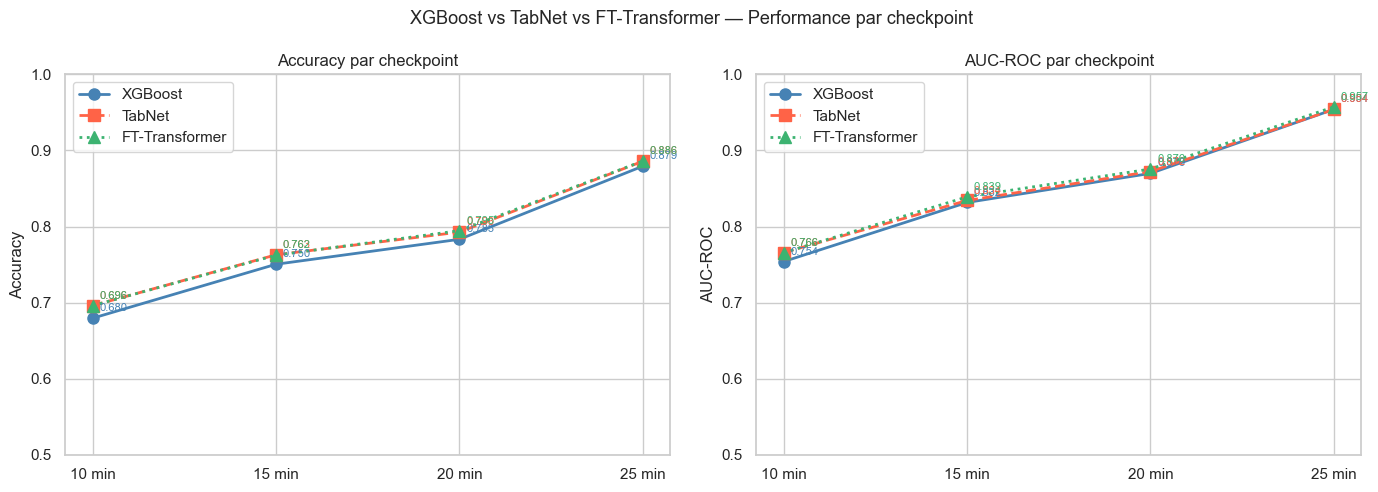

In [6]:
checkpoints = list(results.keys())
acc_xgb_list = [results[c]['xgb']['acc'] for c in checkpoints]
acc_tab_list = [results[c]['tab']['acc'] for c in checkpoints]
acc_ftt_list = [results[c]['ftt']['acc'] for c in checkpoints]
auc_xgb_list = [results[c]['xgb']['auc'] for c in checkpoints]
auc_tab_list = [results[c]['tab']['auc'] for c in checkpoints]
auc_ftt_list = [results[c]['ftt']['auc'] for c in checkpoints]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metrics, title in [
    (axes[0],
     [(acc_xgb_list, 'steelblue',     'o-',  'XGBoost'),
      (acc_tab_list, 'tomato',         's--', 'TabNet'),
      (acc_ftt_list, 'mediumseagreen', '^:',  'FT-Transformer')],
     'Accuracy'),
    (axes[1],
     [(auc_xgb_list, 'steelblue',     'o-',  'XGBoost'),
      (auc_tab_list, 'tomato',         's--', 'TabNet'),
      (auc_ftt_list, 'mediumseagreen', '^:',  'FT-Transformer')],
     'AUC-ROC')
]:
    for values, color, style, label in metrics:
        ax.plot(checkpoints, values, style, color=color, label=label, lw=2, ms=8)
        for i, v in enumerate(values):
            ax.annotate(f'{v:.3f}', (checkpoints[i], v), xytext=(5, 5),
                        textcoords='offset points', color=color, fontsize=8)
    ax.set_title(f'{title} par checkpoint')
    ax.set_ylabel(title)
    ax.set_ylim(0.5, 1.0)
    ax.legend()

plt.suptitle('XGBoost vs TabNet vs FT-Transformer — Performance par checkpoint', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Courbes ROC par checkpoint

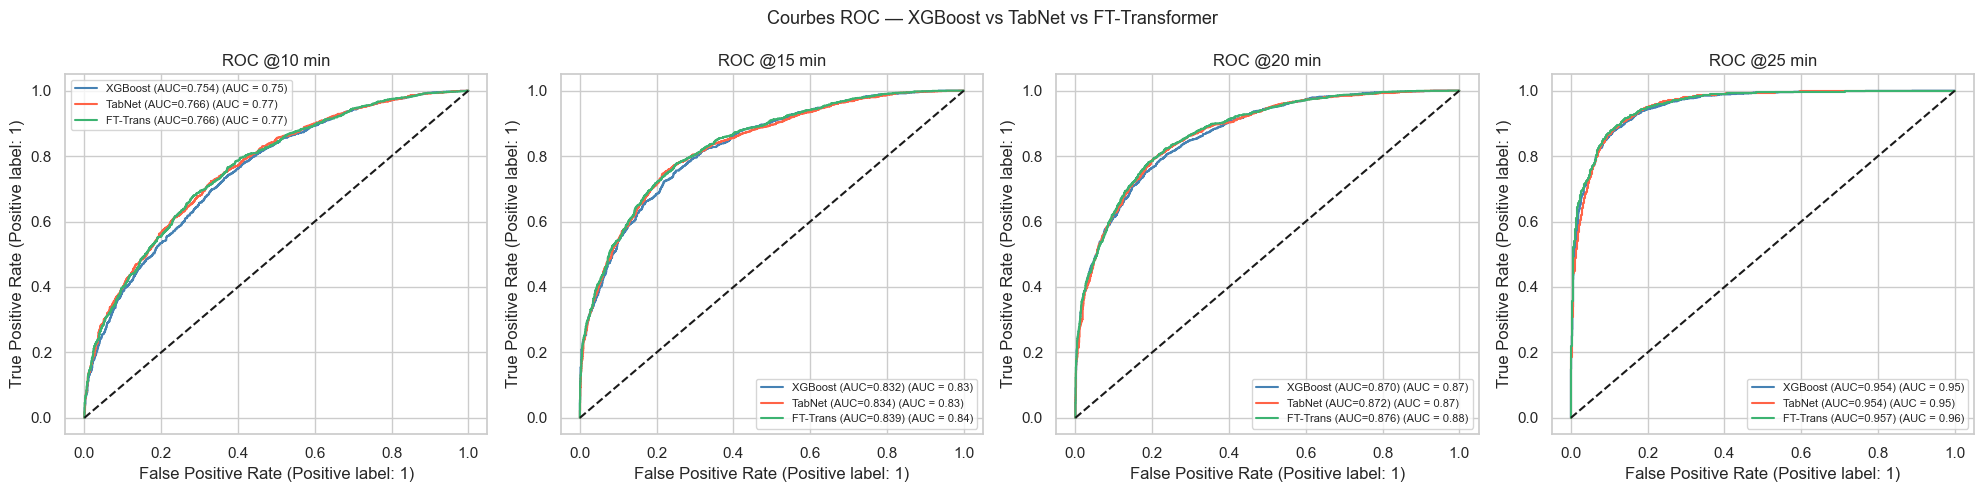

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, name in zip(axes, checkpoints):
    res = results[name]
    RocCurveDisplay.from_predictions(
        res['y_test'], res['xgb']['y_proba'],
        name=f'XGBoost (AUC={res["xgb"]["auc"]:.3f})', ax=ax, color='steelblue')
    RocCurveDisplay.from_predictions(
        res['y_test'], res['tab']['y_proba'],
        name=f'TabNet (AUC={res["tab"]["auc"]:.3f})', ax=ax, color='tomato')
    RocCurveDisplay.from_predictions(
        res['y_test'], res['ftt']['y_proba'],
        name=f'FT-Trans (AUC={res["ftt"]["auc"]:.3f})', ax=ax, color='mediumseagreen')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(f'ROC @{name}')
    ax.legend(fontsize=8)

plt.suptitle('Courbes ROC — XGBoost vs TabNet vs FT-Transformer', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Interprétabilité TabNet — Masques d'attention

L'un des apports majeurs de TabNet est son **interprétabilité native** : les masques d'attention indiquent quelles features ont été utilisées à chaque étape de décision, sans outil externe (SHAP, LIME...).

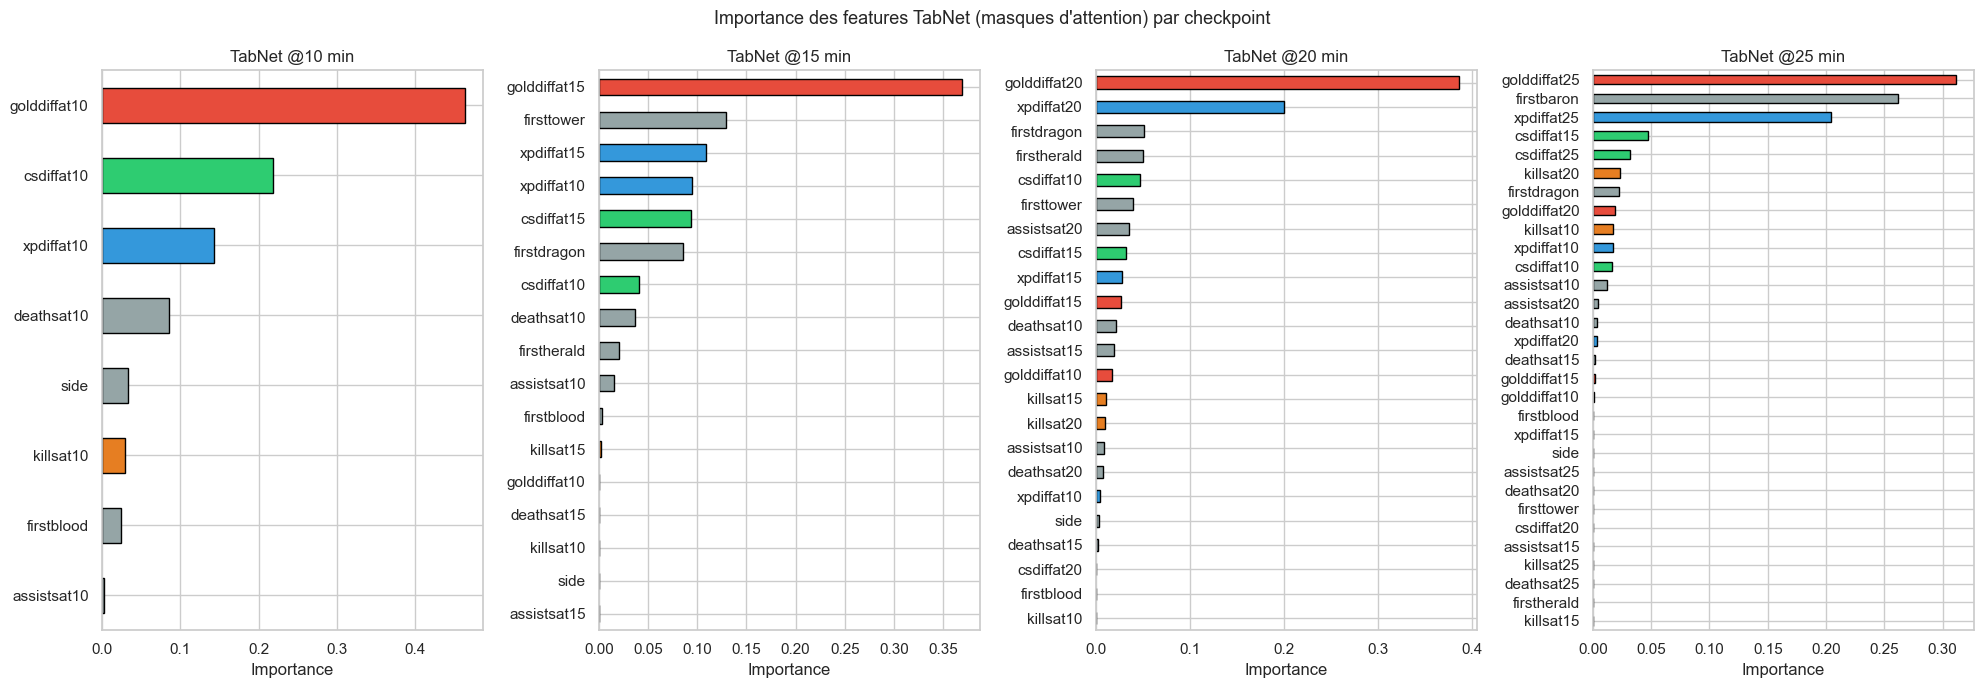

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 7))

for ax, name in zip(axes, checkpoints):
    res = results[name]
    feats = res['feats']
    importances = pd.Series(
        res['tab']['model'].feature_importances_, index=feats
    ).sort_values(ascending=True)
    colors = [
        '#e74c3c' if 'gold' in f else
        '#3498db' if 'xp' in f else
        '#2ecc71' if 'cs' in f else
        '#e67e22' if 'kill' in f else '#95a5a6'
        for f in importances.index
    ]
    importances.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.set_title(f'TabNet @{name}')
    ax.set_xlabel('Importance')

plt.suptitle("Importance des features TabNet (masques d'attention) par checkpoint", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Sauvegarde des modèles

In [9]:
# Sauvegarde des modèles @15 min pour le dashboard (meilleur compromis timing / performance)
res15 = results['15 min']

with open('../models/xgboost/xgb_model.pkl', 'wb') as f:
    pickle.dump(res15['xgb']['model'], f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(res15['scaler'], f)
with open('../models/features.pkl', 'wb') as f:
    pickle.dump(res15['feats'], f)

res15['tab']['model'].save_model('../models/tabnet/tabnet_model')
torch.save(res15['ftt']['model'], '../models/ftt_model.pt')

print('Modèles @15 min sauvegardés pour le dashboard')
print()
print(df_results.to_string(index=False))

# Importances TabNet (explain sur le jeu complet)
X_all_s = res15['scaler'].transform(df[res15['feats']].dropna().values)
M_explain, _ = res15['tab']['model'].explain(X_all_s)
tab_importances = M_explain.mean(axis=0)
with open('../models/tabnet_importances.pkl', 'wb') as f:
    pickle.dump(tab_importances, f)
print('Importances TabNet sauvegardées')

# Sauvegarde de tous les checkpoints
for name, res in results.items():
    tag = name.replace(' ', '')  # '10min', '15min', '20min', '25min'
    with open(f'../models/xgb_{tag}.pkl', 'wb') as f:
        pickle.dump(res['xgb']['model'], f)
    with open(f'../models/scaler_{tag}.pkl', 'wb') as f:
        pickle.dump(res['scaler'], f)
    with open(f'../models/features_{tag}.pkl', 'wb') as f:
        pickle.dump(res['feats'], f)
    res['tab']['model'].save_model(f'../models/tabnet_{tag}')
    torch.save(res['ftt']['model'], f'../models/ftt/ftt_{tag}.pt')
    X_s = res['scaler'].transform(df[res['feats']].dropna().values)
    M, _ = res['tab']['model'].explain(X_s)
    with open(f'../models/tabnet_importances_{tag}.pkl', 'wb') as f:
        pickle.dump(M.mean(axis=0), f)

print('Tous les checkpoints sauvegardés.')

Successfully saved model at tabnet_model.zip
Modèles @15 min sauvegardés pour le dashboard

Checkpoint         Modèle  Accuracy     F1  AUC-ROC
    10 min        XGBoost    0.6796 0.6802   0.7540
    10 min         TabNet    0.6961 0.7036   0.7658
    10 min FT-Transformer    0.6961 0.6914   0.7657
    15 min        XGBoost    0.7505 0.7518   0.8317
    15 min         TabNet    0.7629 0.7649   0.8343
    15 min FT-Transformer    0.7624 0.7651   0.8390
    20 min        XGBoost    0.7833 0.7838   0.8699
    20 min         TabNet    0.7927 0.7933   0.8723
    20 min FT-Transformer    0.7946 0.7922   0.8757
    25 min        XGBoost    0.8794 0.8805   0.9541
    25 min         TabNet    0.8859 0.8877   0.9541
    25 min FT-Transformer    0.8861 0.8882   0.9574


Importances TabNet sauvegardées
Successfully saved model at tabnet_10min.zip


Successfully saved model at tabnet_15min.zip


Successfully saved model at tabnet_20min.zip


Successfully saved model at tabnet_25min.zip


Tous les checkpoints sauvegardés.
